<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/Narx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# NARX POLINOMIAL GENÉRICO
# Treinamento offline para sensor virtual / previsão
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# ============================================================
# 1. Upload do arquivo
# ============================================================

print("Faça upload do arquivo Excel (.xlsx)")
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]
df = pd.read_excel(arquivo)

print("\nColunas encontradas:")
for col in df.columns:
    print("-", col)

Faça upload do arquivo Excel (.xlsx)


Saving Virtual_Sensor.xlsx to Virtual_Sensor.xlsx

Colunas encontradas:
- posicao_valvula
- vazao_teorica
- pressao_controlada


In [5]:
# ============================================================
# 2. Configurações do usuário
# ============================================================

col_y = input("\nDigite o nome da variável de saída Y: ")

n_inputs = int(input("Quantas entradas exógenas o modelo terá? "))

cols_u = []
for i in range(n_inputs):
    col = input(f"Digite o nome da entrada U{i+1}: ")
    cols_u.append(col)

n_lags_y = int(input("Quantos atrasos da saída Y usar? Exemplo: 2: "))
n_lags_u = int(input("Quantos atrasos das entradas U usar? Exemplo: 2: "))
grau_polinomio = int(input("Ordem do polinômio. Exemplo: 1, 2 ou 3: "))

usar_ridge = input("Usar regularização Ridge? (s/n): ").lower() == "s"


Digite o nome da variável de saída Y: pressao_controlada
Quantas entradas exógenas o modelo terá? 2
Digite o nome da entrada U1: vazao_teorica
Digite o nome da entrada U2: posicao_valvula
Quantos atrasos da saída Y usar? Exemplo: 2: 2
Quantos atrasos das entradas U usar? Exemplo: 2: 2
Ordem do polinômio. Exemplo: 1, 2 ou 3: 2
Usar regularização Ridge? (s/n): n


In [6]:
# ============================================================
# 3. Montagem dos atrasos
# ============================================================

data = df.copy()

# atrasos de Y
for lag in range(1, n_lags_y + 1):
    data[f"{col_y}_t-{lag}"] = data[col_y].shift(lag)

# atrasos das entradas
for col in cols_u:
    for lag in range(1, n_lags_u + 1):
        data[f"{col}_t-{lag}"] = data[col].shift(lag)

data = data.dropna().reset_index(drop=True)

feature_cols = [c for c in data.columns if "_t-" in c]

X_base = data[feature_cols]
y = data[col_y]

print("\nVariáveis usadas no modelo:")
for c in feature_cols:
    print("-", c)


Variáveis usadas no modelo:
- pressao_controlada_t-1
- pressao_controlada_t-2
- vazao_teorica_t-1
- vazao_teorica_t-2
- posicao_valvula_t-1
- posicao_valvula_t-2


In [7]:
# ============================================================
# 4. Separação treino/teste temporal
# ============================================================

train_size = int(len(data) * 0.8)

X_train_base = X_base.iloc[:train_size]
X_test_base  = X_base.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]


In [9]:
# ============================================================
# 5. Normalização
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled  = scaler.transform(X_test_base)

In [10]:
# ============================================================
# 6. Expansão polinomial
# ============================================================

poly = PolynomialFeatures(
    degree=grau_polinomio,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

nomes_features = poly.get_feature_names_out(feature_cols)

print(f"\nNúmero de termos do modelo polinomial: {len(nomes_features)}")


Número de termos do modelo polinomial: 27


In [11]:
# ============================================================
# 7. Treinamento do modelo
# ============================================================

if usar_ridge:
    alpha = float(input("Digite o alpha da Ridge. Exemplo: 0.1, 1, 10: "))
    modelo = Ridge(alpha=alpha)
else:
    modelo = LinearRegression()

modelo.fit(X_train_poly, y_train)

LinearRegression()

In [12]:
# ============================================================
# 8. Predição
# ============================================================

y_pred_train = modelo.predict(X_train_poly)
y_pred_test  = modelo.predict(X_test_poly)

In [13]:
# ============================================================
# 9. Métricas
# ============================================================

def calcular_metricas(y_real, y_pred, nome):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    print(f"\nMétricas - {nome}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

calcular_metricas(y_train, y_pred_train, "Treino")
calcular_metricas(y_test, y_pred_test, "Teste")


Métricas - Treino
MAE  = 0.1922
RMSE = 0.4319
R²   = 0.9994

Métricas - Teste
MAE  = 0.2965
RMSE = 0.5506
R²   = 0.9995


In [14]:
# ============================================================
# 10. Coeficientes aprendidos
# ============================================================

coeficientes = pd.DataFrame({
    "Termo": nomes_features,
    "Coeficiente": modelo.coef_
})

coeficientes["Abs"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values("Abs", ascending=False)

print("\nBias / Intercepto:")
print(modelo.intercept_)

print("\nPrincipais coeficientes:")
display(coeficientes.head(20))


Bias / Intercepto:
73.32849766985376

Principais coeficientes:


,Termo,Coeficiente,Abs
0,pressao_controlada_t-1,29.013069,29.013069
8,pressao_controlada_t-1 vazao_teorica_t-1,15.734009,15.734009
9,pressao_controlada_t-1 vazao_teorica_t-2,-15.440121,15.440121
13,pressao_controlada_t-2 vazao_teorica_t-1,-14.786345,14.786345
14,pressao_controlada_t-2 vazao_teorica_t-2,14.450273,14.450273
1,pressao_controlada_t-2,-11.823974,11.823974
7,pressao_controlada_t-1 pressao_controlada_t-2,9.128017,9.128017
22,vazao_teorica_t-2 posicao_valvula_t-1,7.236594,7.236594
19,vazao_teorica_t-1 posicao_valvula_t-1,-6.935230,6.935230
10,pressao_controlada_t-1 posicao_valvula_t-1,6.376171,6.376171


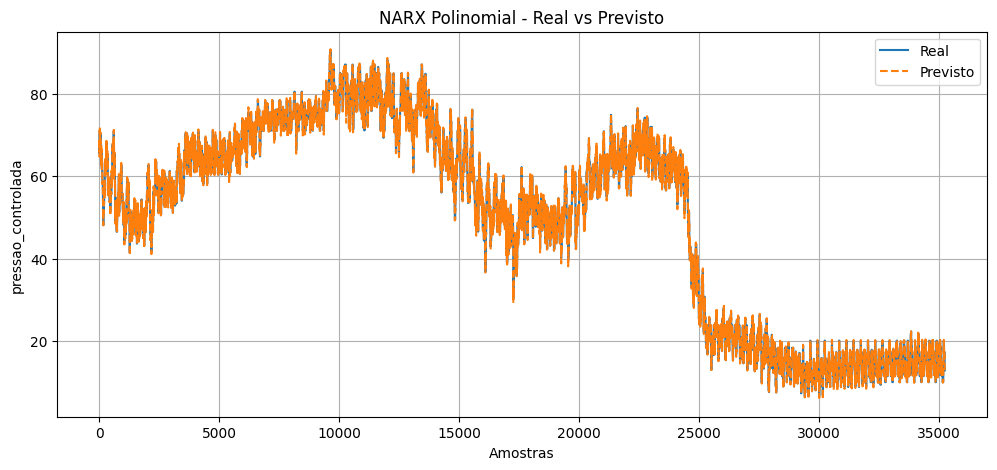

In [15]:
# ============================================================
# 11. Gráfico real vs previsto
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_test, label="Previsto", linestyle="--")
plt.title("NARX Polinomial - Real vs Previsto")
plt.xlabel("Amostras")
plt.ylabel(col_y)
plt.legend()
plt.grid(True)
plt.show()


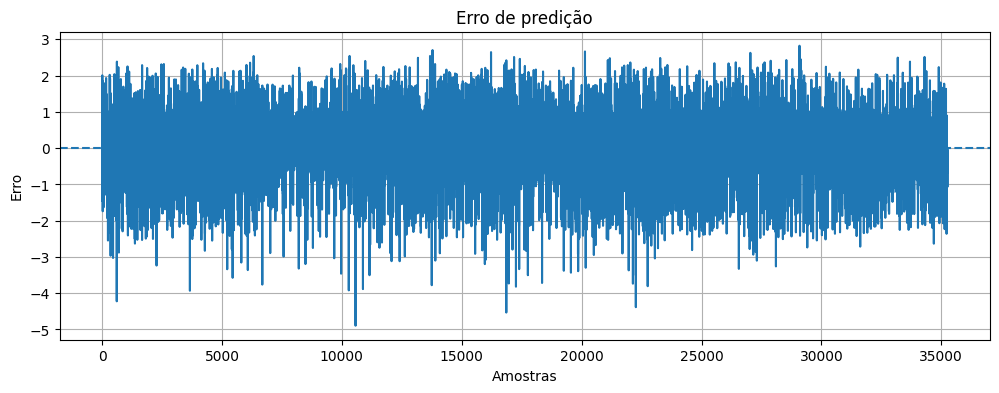

In [16]:
# ============================================================
# 12. Gráfico do erro
# ============================================================

erro = y_test.values - y_pred_test

plt.figure(figsize=(12,4))
plt.plot(erro)
plt.axhline(0, linestyle="--")
plt.title("Erro de predição")
plt.xlabel("Amostras")
plt.ylabel("Erro")
plt.grid(True)
plt.show()

In [17]:
# ============================================================
# 13. Exportar coeficientes
# ============================================================

coeficientes_export = pd.DataFrame({
    "Termo": nomes_features,
    "Coeficiente": modelo.coef_
})

coeficientes_export.loc[len(coeficientes_export)] = ["Bias", modelo.intercept_]

coeficientes_export.to_excel("coeficientes_narx_polinomial.xlsx", index=False)

files.download("coeficientes_narx_polinomial.xlsx")

print("\nArquivo coeficientes_narx_polinomial.xlsx gerado com sucesso.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Arquivo coeficientes_narx_polinomial.xlsx gerado com sucesso.
